# Week 07 (Module 18) - BBO capstone driver

Round 7. New this week: **partition-BO** (`partition_bo.py`), a separate process mimicking the JetBrains NeurIPS 2020 BBO Challenge entry (Sazanovich et al., 3rd place): cluster known points by score (KMeans), learn the good-region boundary with an RBF-kernel SVM, recurse up to depth 5, then run EI with a LOCAL GP over Sobol candidates confined to the learned region.

Why: the global GP assumes one smoothness everywhere (stationarity), which is clearly wrong for f5's sharp corner and behind f4's repeated over-confident misses. A local model over a learned good region sidesteps both.

**Hybrid plan this round:**
- **f1 → space_fill** (still a lottery; centre coverage)
- **f2 → partition** (refines near the 0.611 incumbent instead of wandering)
- **f3 → EI** (the planned promotion test after two stable weeks of R²)
- **f4 → partition** (deliberate risk: local GP predicts 2.77 ± 1.25, far above anything observed - but the candidate is confined to the SVM-classified good region, unlike the W4/W6 failures)
- **f5 → space_fill** (deep-unexplored-quadrant probe for a hidden global; (1,1,1,1)=8662 is locked only in the FINAL week)
- **f6 → partition** (region constraint safer than AEI under an untrustworthy model)
- **f7 → partition** (the standout: proposes right next to the W2 winner 1.688 - the pull-back-and-refine move f7 has needed for 4 weeks)
- **f8 → partition** (breaks MES's convergence AND lands on x5=0.93 - matching the RF importance flag and Omkar's high-x5 clue)


In [1]:
%matplotlib inline
import os, sys, warnings
warnings.filterwarnings("ignore")
_root = os.getcwd()
while not os.path.exists(os.path.join(_root, "bo.py")) and os.path.dirname(_root) != _root:
    _root = os.path.dirname(_root)
os.chdir(_root); sys.path.insert(0, _root)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import bo, partition_bo

WEEK = 7
SEED = 0

# Hybrid plan: current pipeline for f1/f3/f5, partition-BO for the rest.
BO_PLAN   = {1: dict(acq="space_fill"), 3: dict(acq="ei", xi=0.01), 5: dict(acq="space_fill")}
PART_FIDS = [2, 4, 6, 7, 8]

OUTDIR = f"outputs/week{WEEK:02d}"
os.makedirs(OUTDIR, exist_ok=True)

results = {}
for fid, plan in BO_PLAN.items():
    results[fid] = bo.run_function(fid, seed=SEED, **plan)
for fid in PART_FIDS:
    r = partition_bo.propose(fid, seed=SEED)
    m = bo.fit(fid)
    r["acq_all"] = {k: float(v[0]) for k, v in bo.acq_values(m, r["u"].reshape(1, -1)).items()}
    r["incumbent_y"], r["n_data"], r["model"] = m.y_best, len(m.y), m
    results[fid] = r

pd.DataFrame([dict(func=f"f{fid}", acq=results[fid]["acq"],
                   incumbent=round(results[fid]["incumbent_y"], 4),
                   pred=round(results[fid]["mean"], 4), std=round(results[fid]["std"], 4),
                   submission=results[fid]["submission"]) for fid in bo.FUNC_IDS])


,func,acq,incumbent,pred,std,submission
0,f1,space_fill,0.0000,-0.0001,0.0007,0.407463-0.465698
1,f2,partition_ei,0.6112,0.6124,0.0341,0.689312-0.981023
2,f3,ei,-0.0348,-0.0335,0.0351,0.121596-0.000000-0.864840
3,f4,partition_ei,0.5401,2.7715,1.2467,0.407035-0.346816-0.622541-0.487786
4,f5,space_fill,8662.4050,1213.6375,308.0154,0.185156-0.016903-0.328554-0.982614
5,f6,partition_ei,-0.7048,-0.6267,0.1215,0.698838-0.250304-0.856490-0.970109-0.319210
6,f7,partition_ei,1.6876,1.5928,0.1245,0.079248-0.114096-0.014955-0.023388-0.376230-0...
7,f8,partition_ei,9.9498,10.1271,0.1440,0.057249-0.218562-0.219367-0.966093-0.934303-0...


## 1. Data - seed the working CSVs and review the function descriptions

In [2]:
bo.seed_csvs()          # data/f1..f8.csv from initial_data/*.npy (no-op once they exist)
bo.write_descriptions() # data/function_descriptions.csv
pd.read_csv("data/function_descriptions.csv")[["func", "dims", "n_seed", "character", "application"]]

,func,dims,n_seed,character,application
0,1,2,10,Sparse/flat (mostly ~0 except near sources); m...,Radiation/contamination source detection in a ...
1,2,2,10,Noisy + multimodal with many local peaks.,Mystery ML model returning a noisy log-likelih...
2,3,3,15,Maximise a negated cost (toward 0).,Drug discovery: combinations of three compound...
3,4,4,30,Dynamic with many local optima.,Warehouse product-placement surrogate; output ...
4,5,4,20,"Typically unimodal, a single peak.",Chemical-process yield.
5,6,5,20,Negative-by-design; maximise toward 0.,Cake recipe with five ingredients; combined ne...
6,7,6,30,Black-box; literature priors can inform the se...,"ML hyperparameter tuning (lr, reg, #layers...)..."
7,8,8,40,High-dimensional; global optimisation hard.,"8-param ML hyperparameter tuning (lr, batch, l..."


## 2. Fit a surrogate and propose the next query for all 8 functions

In [3]:
summary = pd.DataFrame([
    dict(func=f"f{fid}", d=len(results[fid]["x"]), n_data=results[fid]["n_data"],
         incumbent_y=round(results[fid]["incumbent_y"], 4),
         pred_mean=round(results[fid]["mean"], 4) if results[fid]["mean"]==results[fid]["mean"] else None,
         pred_std=round(results[fid]["std"], 4) if results[fid]["std"]==results[fid]["std"] else None,
         acq_used=results[fid]["acq"], submission=results[fid]["submission"])
    for fid in bo.FUNC_IDS
])
summary


,func,d,n_data,incumbent_y,pred_mean,pred_std,acq_used,submission
0,f1,2,16,0.0000,-0.0001,0.0007,space_fill,0.407463-0.465698
1,f2,2,16,0.6112,0.6124,0.0341,partition_ei,0.689312-0.981023
2,f3,3,21,-0.0348,-0.0335,0.0351,ei,0.121596-0.000000-0.864840
3,f4,4,36,0.5401,2.7715,1.2467,partition_ei,0.407035-0.346816-0.622541-0.487786
4,f5,4,26,8662.4050,1213.6375,308.0154,space_fill,0.185156-0.016903-0.328554-0.982614
5,f6,5,26,-0.7048,-0.6267,0.1215,partition_ei,0.698838-0.250304-0.856490-0.970109-0.319210
6,f7,6,36,1.6876,1.5928,0.1245,partition_ei,0.079248-0.114096-0.014955-0.023388-0.376230-0...
7,f8,8,46,9.9498,10.1271,0.1440,partition_ei,0.057249-0.218562-0.219367-0.966093-0.934303-0...


### Acquisition values at each proposed point
All four acquisitions are computed every round so the choice can be justified in the reflection.

In [4]:
for fid in bo.FUNC_IDS:
    r = results[fid]
    if "acq_all" not in r:
        m = r.get("model") or bo.fit(fid)
        r["model"] = m
        r["acq_all"] = {k: float(v[0]) for k, v in bo.acq_values(m, np.atleast_2d(r["u"])).items()}
pd.DataFrame([
    dict(func=f"f{fid}", **{k: round(v, 4) for k, v in results[fid]["acq_all"].items()})
    for fid in bo.FUNC_IDS
])


,func,ei,ucb,pi,var
0,f1,0.0000,0.0013,0.0000,0.0000
1,f2,0.0059,0.6745,0.2437,0.0017
2,f3,0.0101,0.0368,0.4025,0.0012
3,f4,0.0000,-2.4797,0.0000,0.6006
4,f5,0.0000,1829.6682,0.0000,94873.4679
5,f6,0.0177,-0.5018,0.1856,0.0305
6,f7,0.0139,1.8418,0.2000,0.0155
7,f8,0.0003,9.7924,0.0038,0.0622


## 3. Visualise
2D functions get full posterior + acquisition heatmaps; higher-D functions get 1D slices
through the incumbent. Every function gets convergence + leave-one-out diagnostics.

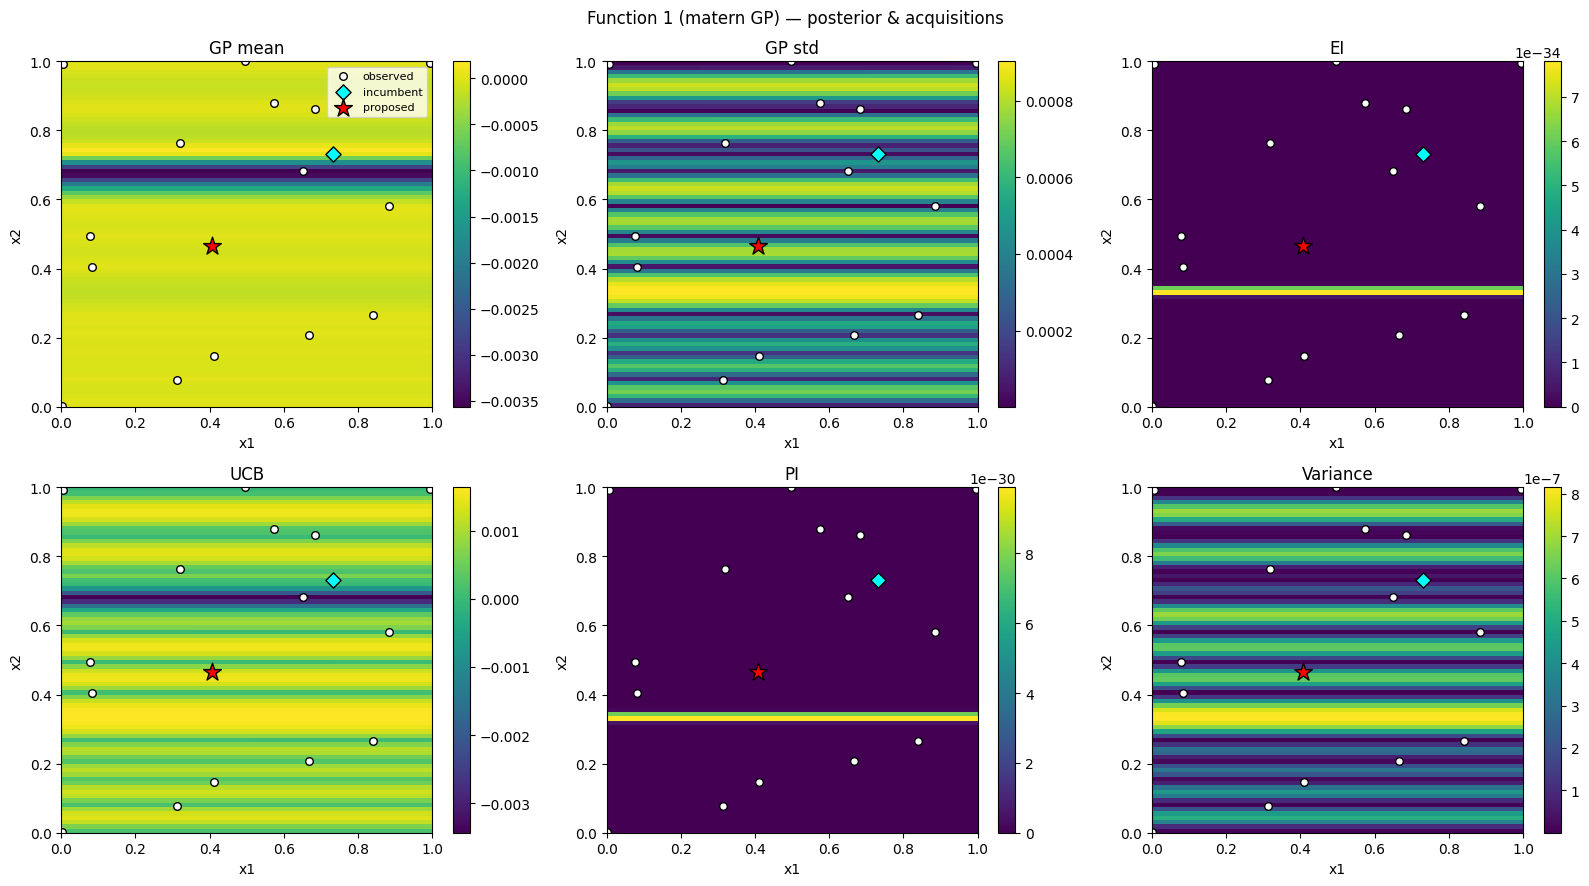

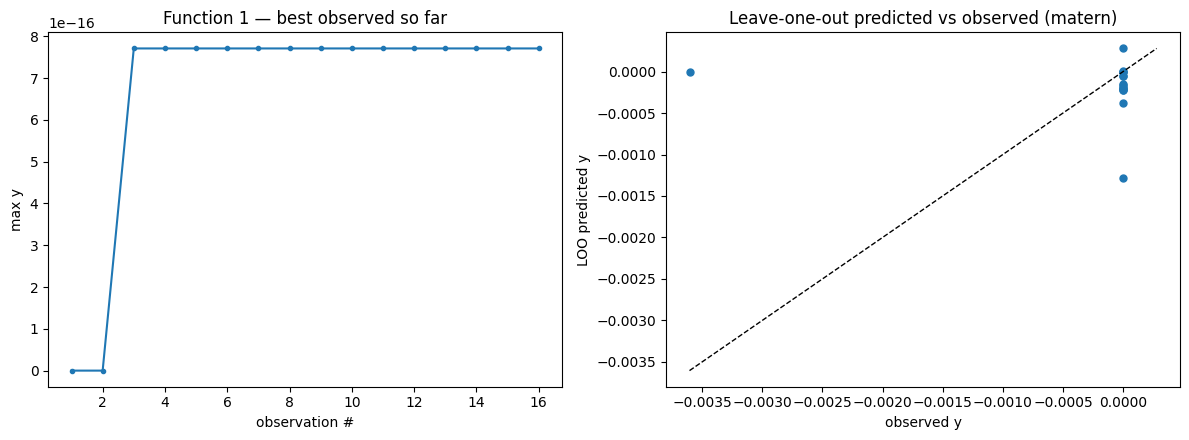

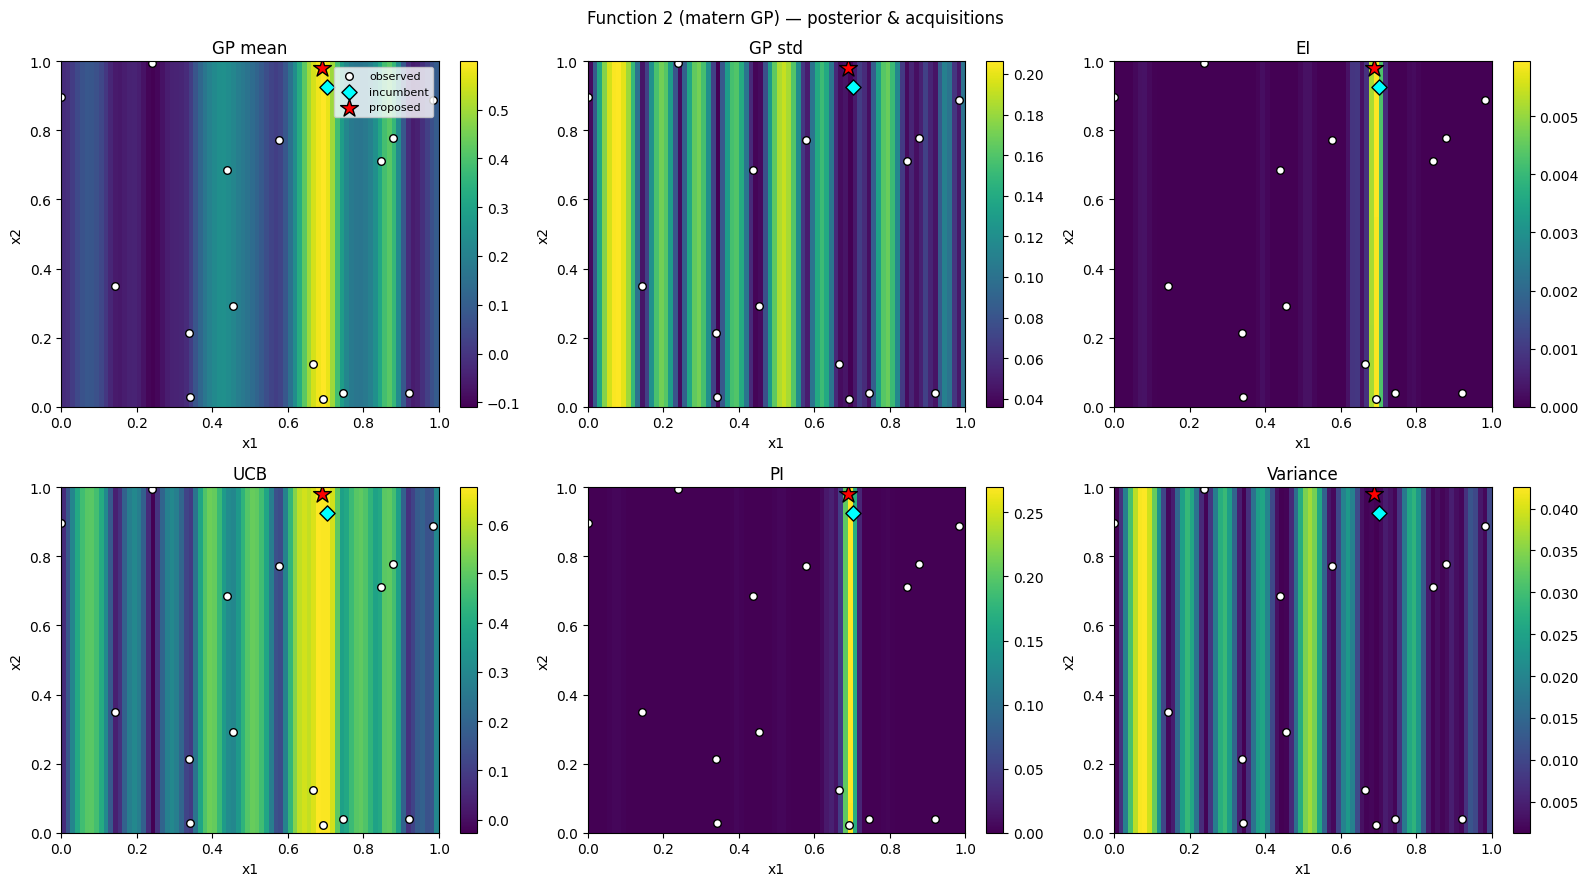

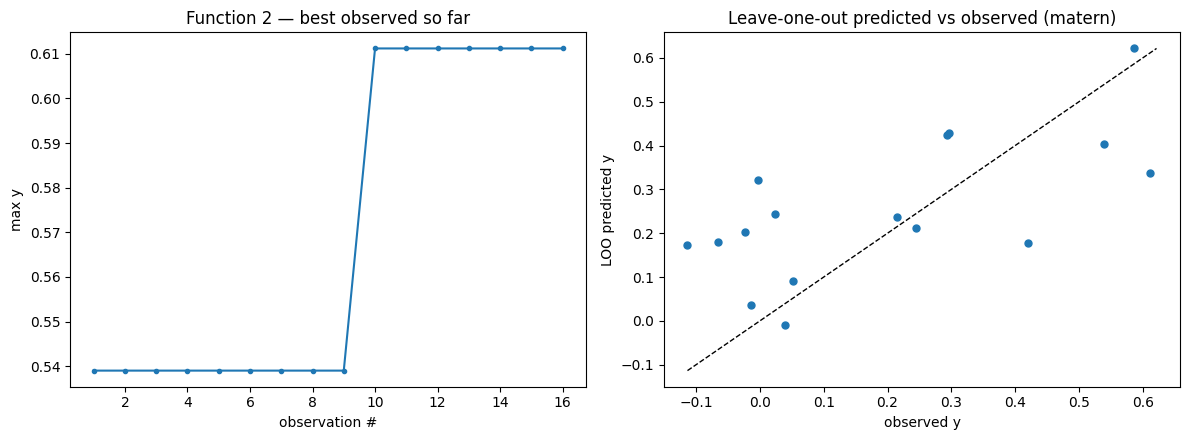

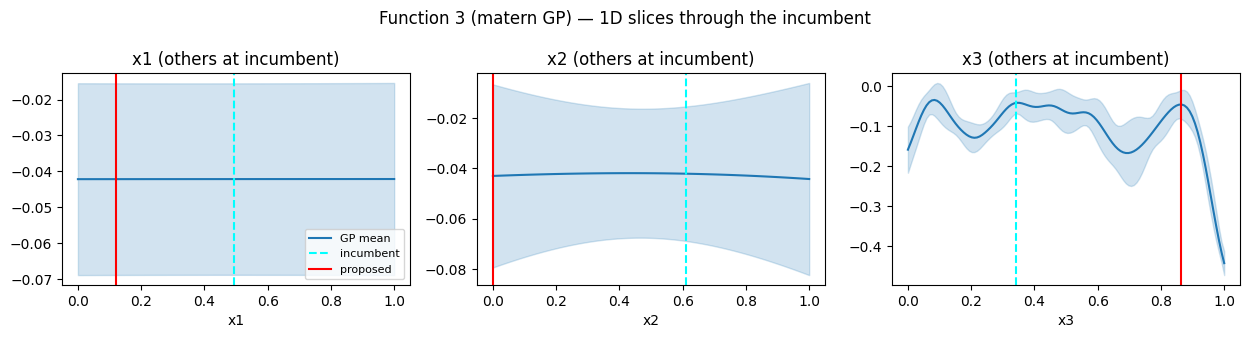

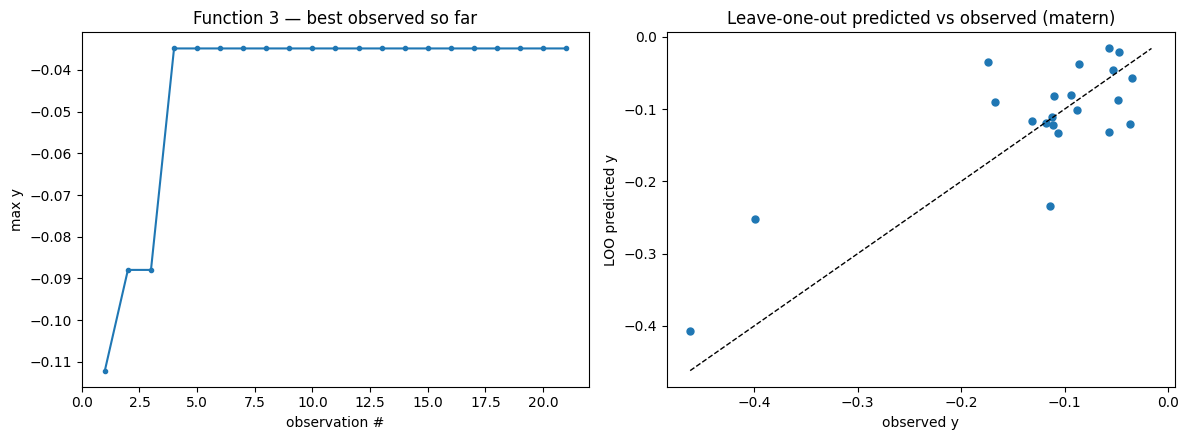

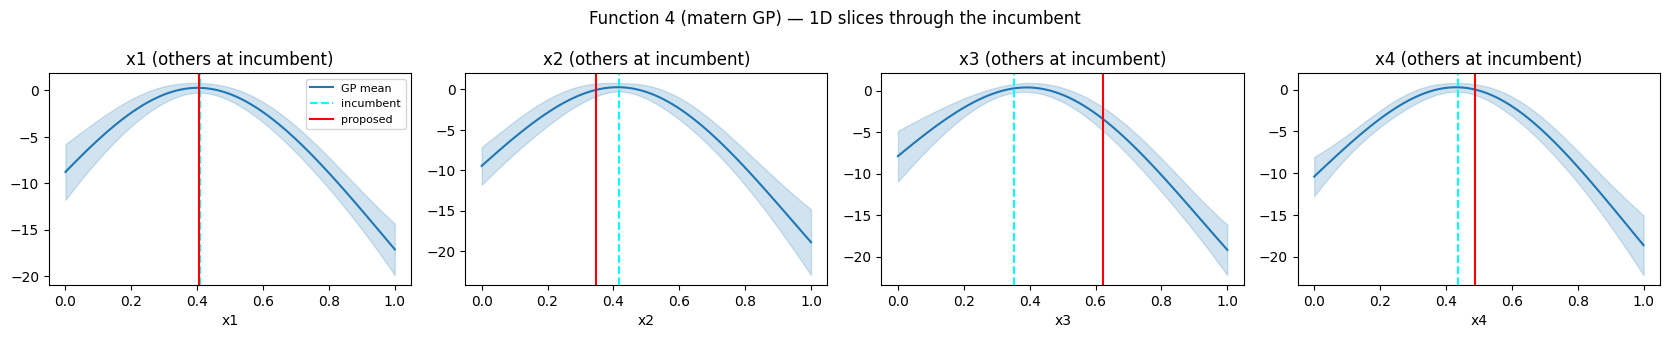

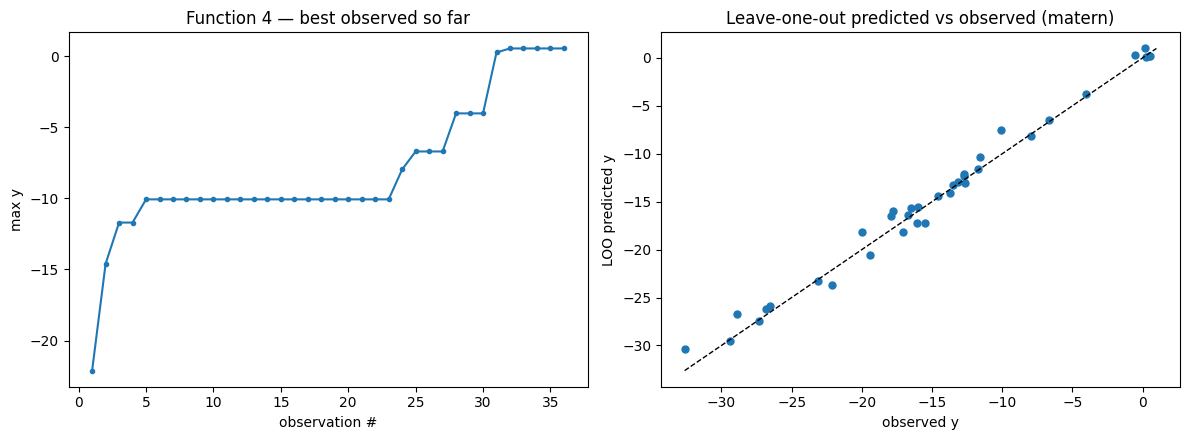

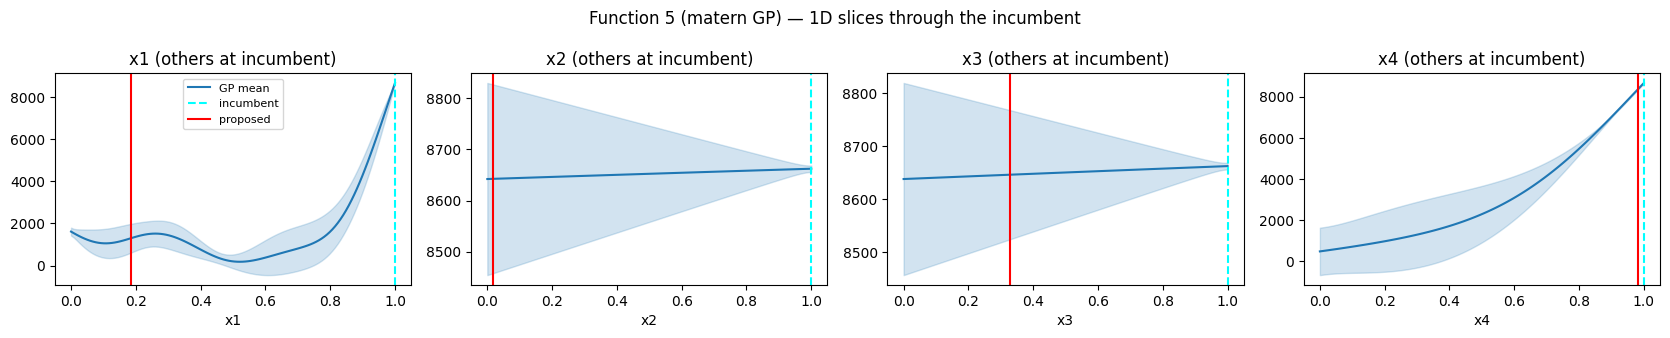

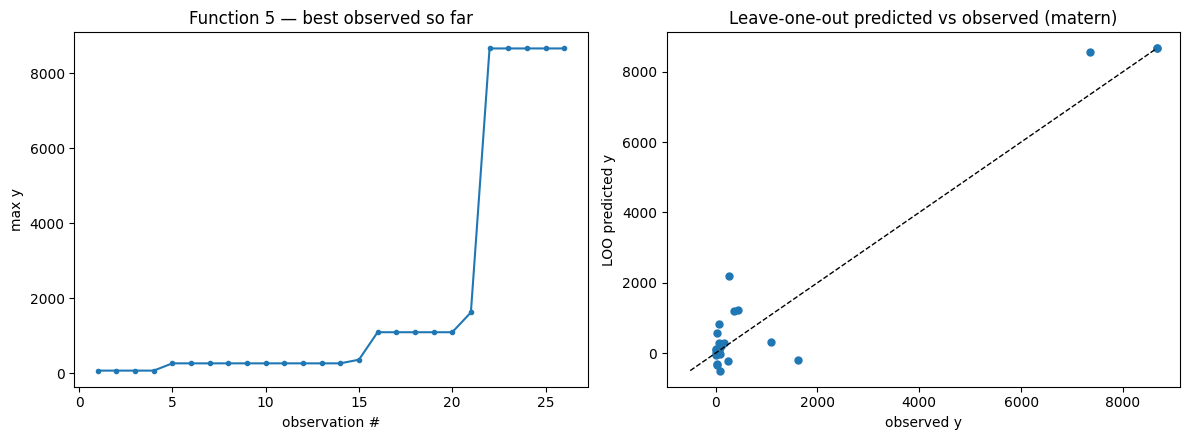

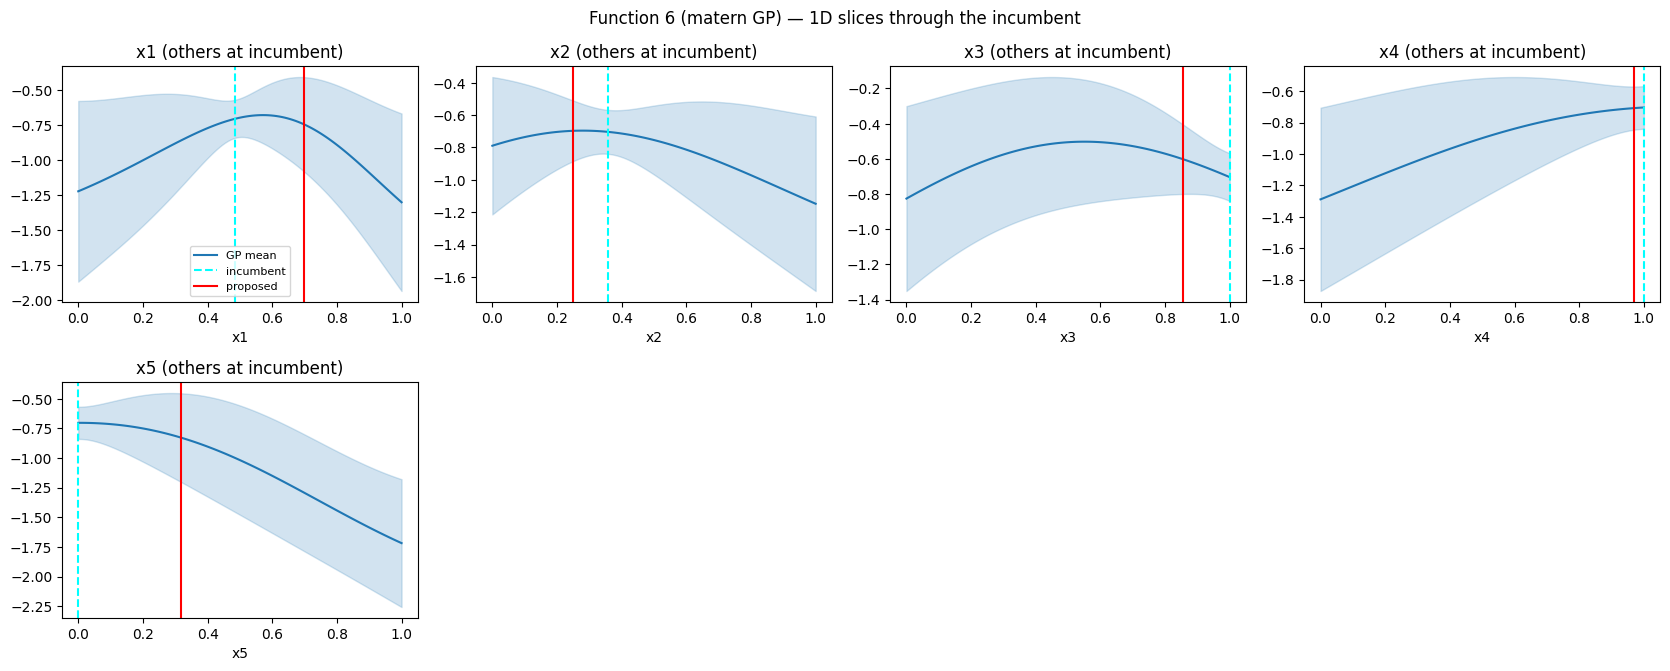

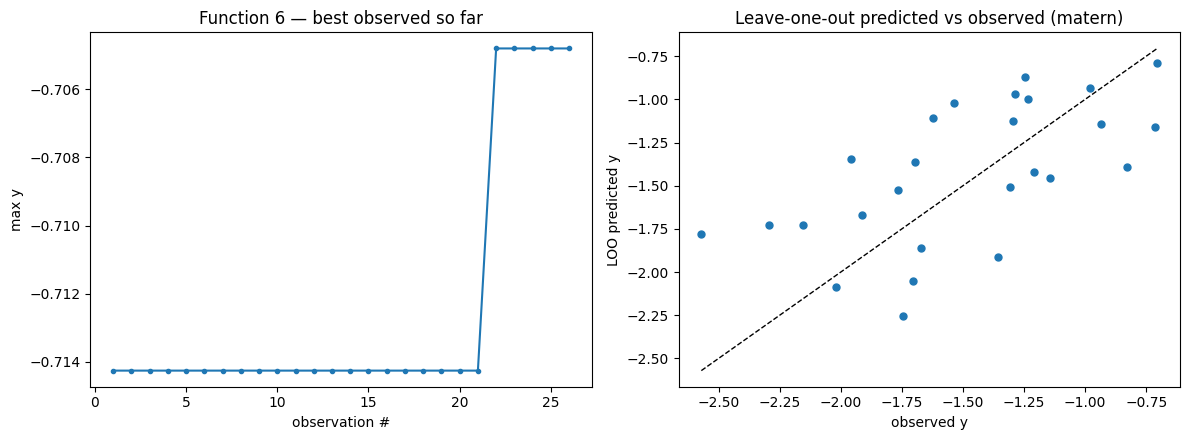

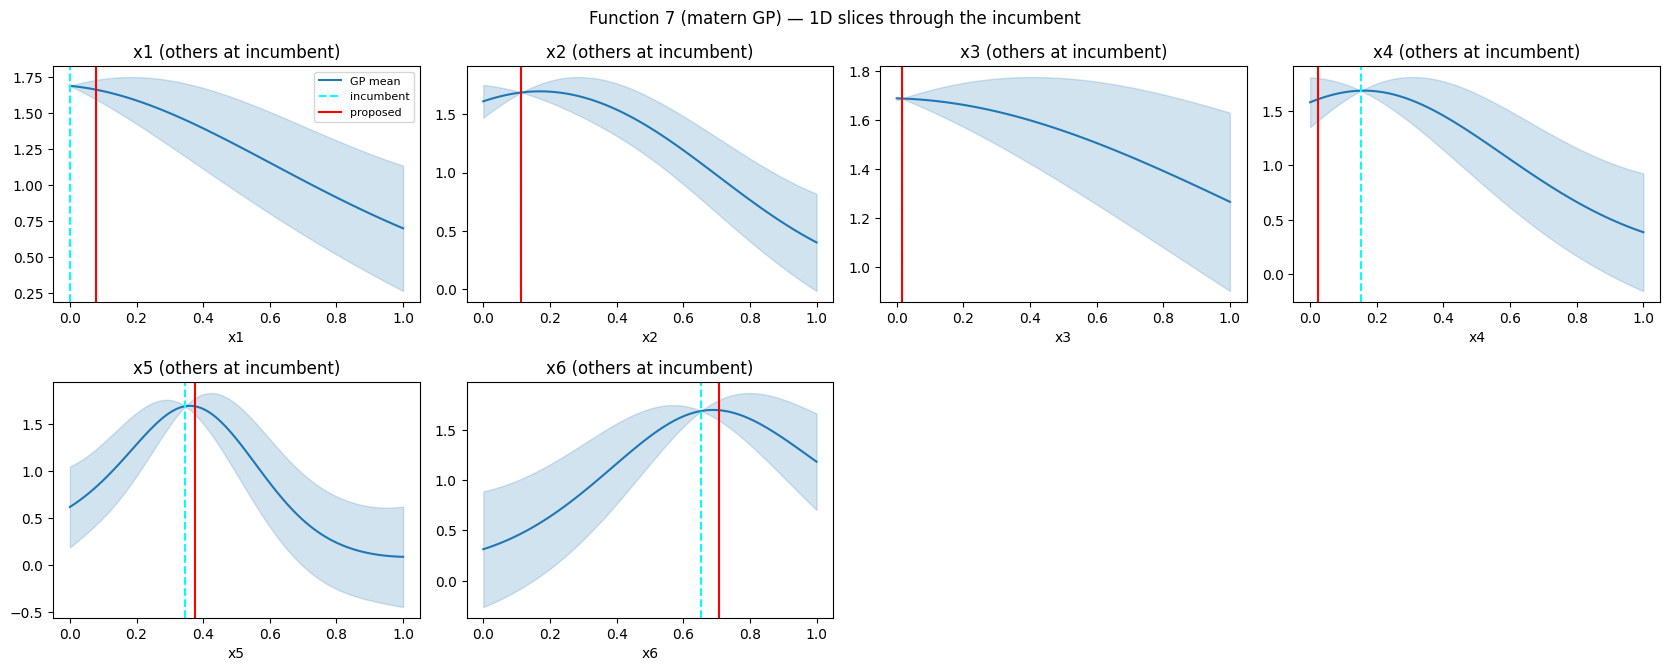

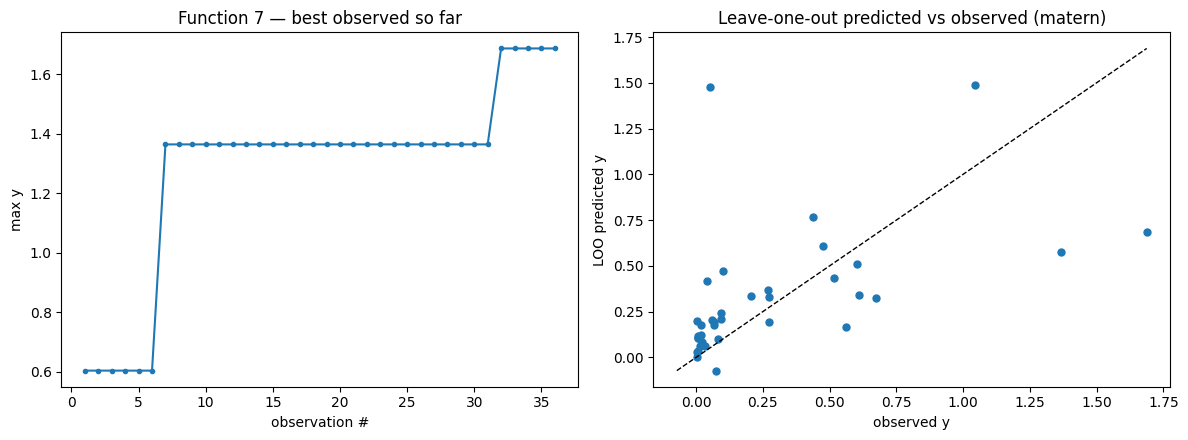

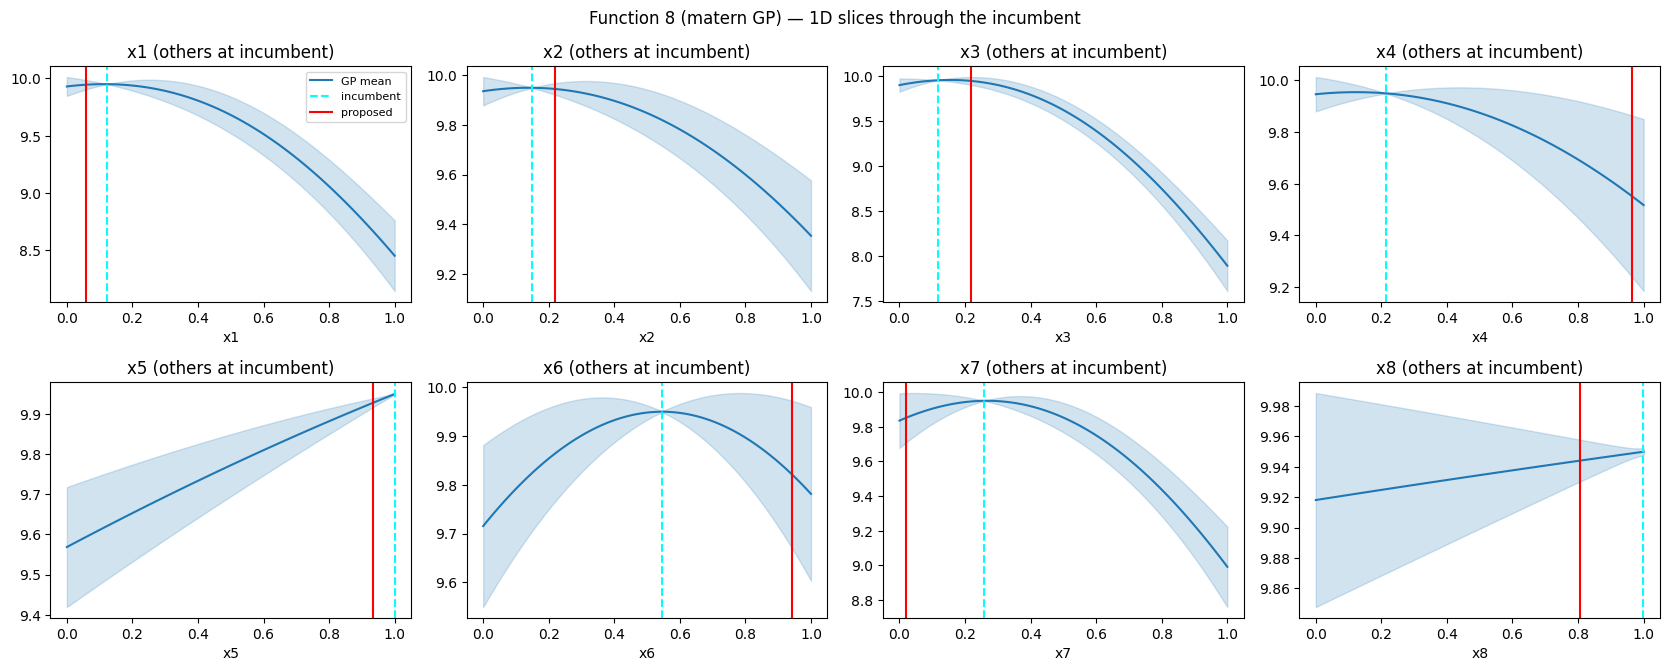

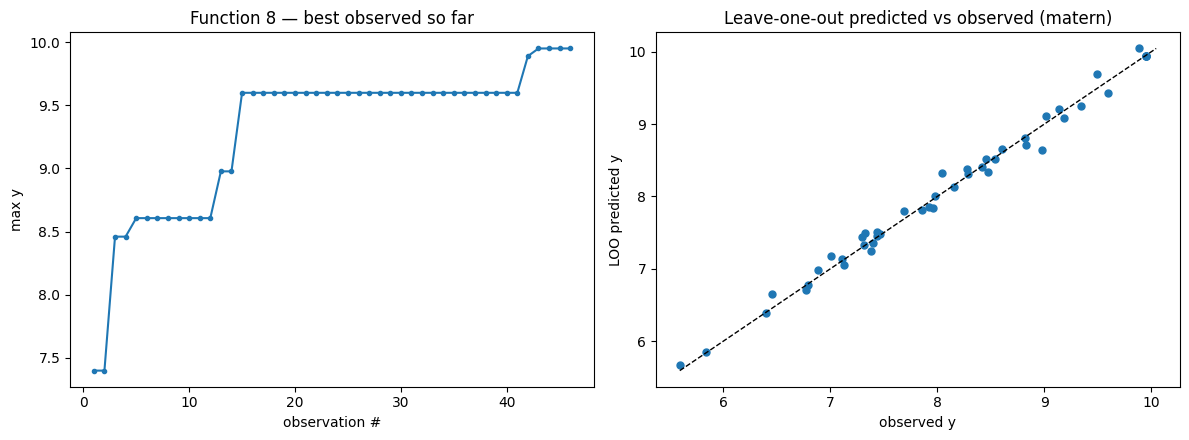

In [5]:
for fid in bo.FUNC_IDS:
    r = results[fid]; m = r.get("model") or bo.fit(fid)
    if m.d == 2:
        bo.plot_2d(m, proposed=r["x"], save=f"{OUTDIR}/f{fid}_2d.png")
    else:
        bo.plot_slices(m, proposed_u=r["u"], save=f"{OUTDIR}/f{fid}_slices.png")
    bo.plot_diagnostics(m, save=f"{OUTDIR}/f{fid}_diag.png")
    plt.show()


## 4. Submission strings - copy one per function into the portal

In [6]:
for fid in bo.FUNC_IDS:
    print(f"f{fid}:  {results[fid]['submission']}")

f1:  0.407463-0.465698
f2:  0.689312-0.981023
f3:  0.121596-0.000000-0.864840
f4:  0.407035-0.346816-0.622541-0.487786
f5:  0.185156-0.016903-0.328554-0.982614
f6:  0.698838-0.250304-0.856490-0.970109-0.319210
f7:  0.079248-0.114096-0.014955-0.023388-0.376230-0.707327
f8:  0.057249-0.218562-0.219367-0.966093-0.934303-0.942544-0.019275-0.806582


## 5. Write the weekly reflection scaffold
Creates `weekly/reflections/weekNN.md` if it doesn't exist yet. It will **not** overwrite a
reflection you've already written (pass `overwrite=True` to force a fresh scaffold).

In [7]:
path = bo.render_reflection(WEEK, results)   # won't overwrite an already-written reflection
print("reflection ->", path)


reflection -> /Users/jp/PycharmProjects/MachineLearning/Capstone/weekly/reflections/week07.md


## 6. After the portal returns each y - record results for next round
Fill in the returned outputs below, run the cell, then bump `WEEK` and re-run the notebook
next module. `append_result` grows each function's CSV by one row.

In [8]:
# Week 7 portal returns - already saved into data/fN.csv outside the notebook.
# returned_y = {
#     1: -0.005338563332198497,
#     2: 0.404159096545482,
#     3: -0.0951041900765629,
#     4: -4.734816906524692,
#     5: 154.2173749658613,
#     6: -0.9605422015994186,
#     7: 1.030689594663073,
#     8: 9.0272222860751,
# }
#
# Comparison vs week-6 incumbents:
#   f1 -0.0053 - FIRST NON-ZERO READING in 7 weeks. Negative, at (0.407, 0.466).
#      The field isn't perfectly flat - there is structure near the centre. Probe nearby next week.
#   f2 0.404 vs 0.611 (partition predicted 0.612 +/- 0.034; ~6 sigma miss - f2 noise/nonstationarity)
#   f3 -0.095 vs -0.035 (EI promotion missed slightly)
#   f4 -4.73 vs 0.54 (partition predicted 2.77; THIRD confident f4 failure - its good region is razor thin)
#   f5 154 vs 8662 (another quadrant ruled out; consistent with single sharp peak at (1,1,1,1))
#   f6 -0.96 vs -0.705 (partition mild miss)
#   f7 1.031 vs 1.688 (partition predicted 1.59; best f7 return in 5 weeks but below incumbent - neighbourhood decent, peak sharp)
#   f8 9.027 vs 9.9498 (partition predicted 10.13; HIGH-x5 HUNCH DISPROVEN - the MES point stays best)
#
# Net: zero new bests; partition went 0-for-5 on its debut. Honest scorecard:
#   - Its predictions were over-confident everywhere except f7 (decent neighbourhood, right idea).
#   - The high-x5 signal (RF + peer + partition) did NOT survive contact with the portal.
#   - f1's first real reading is the most valuable single number this round.
# for fid, y in returned_y.items():
#     bo.append_result(fid, results[fid]["x"], y)
# print("saved; dataset sizes now:", {fid: len(bo.load(fid)[1]) for fid in bo.FUNC_IDS})
